<a href="https://colab.research.google.com/github/mokshManchandani/data-science/blob/deeplearning-pytorch-udemy/overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Manual seperation using numpy

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-613cd1fd3f9c>:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [ ]:
iris = sns.load_dataset('iris')
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X = torch.tensor(iris.drop('species', axis=1).values).float()
Y = torch.zeros(len(X), dtype=torch.long)
Y[iris['species'] == 'versicolor'] = 1
Y[iris['species'] == 'virginica'] = 2
Y.shape, X.shape, Y.unique()

(torch.Size([150]), torch.Size([150, 4]), tensor([0, 1, 2]))

In [ ]:
# train size = .8
propTraining = .8
nTraining = int(len(X) * propTraining)
indices_map = np.zeros(len(Y), dtype=bool)
train_indices = np.random.choice(range(len(Y)), nTraining, replace=False)
indices_map[train_indices] = True
X_train, X_test = X[indices_map], X[~indices_map]
Y_train, Y_test = Y[indices_map], Y[~indices_map]

In [ ]:
# check for balance accross the labels in all sets
torch.mean(Y.float()), torch.mean(Y_train.float()), torch.mean(Y_test.float())

(tensor(1.), tensor(1.0167), tensor(0.9333))

In [ ]:
model = nn.Sequential(
  nn.Linear(4,64),
  nn.ReLU(),
  nn.Linear(64,64),
  nn.ReLU(),
  nn.Linear(64, 3)
)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = .01)

In [ ]:
X.shape, X_train.shape, X_test.shape

(torch.Size([150, 4]), torch.Size([120, 4]), torch.Size([30, 4]))

In [ ]:
num_epochs = 1000
ongoing_acc = []
losses = torch.zeros(num_epochs)

for i, epoch in enumerate(range(num_epochs)):
  y_hat = model(X_train)
  loss = loss_func(y_hat, Y_train)
  losses[i] = loss
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  acc = (torch.argmax(y_hat, dim=1) == Y_train).float().mean()
  ongoing_acc.append(acc * 100)



In [ ]:
predictions = model(X_train)
train_acc = 100 * ((torch.argmax(predictions, dim=1) == Y_train)).float().mean()

predictions = model(X_test)
test_acc = 100 * ((torch.argmax(predictions, dim=1) == Y_test)).float().mean()

print(f'Train accuracy: {train_acc:.2f}\nTest accuracy: {test_acc:.2f}')

Train accuracy: 98.33
Test accuracy: 96.67


Additional Explorations number 1

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-a08d4dd010ec>:7: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [ ]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X = torch.tensor(iris.drop('species', axis=1).values).float()
Y = torch.zeros(len(X), dtype=torch.long)
Y[iris['species'] == 'versicolor'] = 1
Y[iris['species'] == 'virginica'] = 2
X.shape, Y.shape,Y.unique()

(torch.Size([150, 4]), torch.Size([150]), tensor([0, 1, 2]))

In [ ]:
# indices for Y == 0
training_proportion = .8
n_training_part = int((len(X) * training_proportion) / 3)
train_map = np.zeros(len(Y), dtype=bool)
class_0_indices  = np.where(Y == 0)[0]
class_1_indices = np.where(Y == 1)[0]
class_2_indices = np.where(Y == 2)[0]
train_class_0_indices = np.random.choice(class_0_indices, n_training_part, replace=False)
train_1_indices = np.random.choice(class_1_indices, n_training_part, replace=False)
train_2_indices = np.random.choice(class_2_indices, n_training_part, replace=False)
all_indices = np.hstack([train_class_0_indices, train_1_indices, train_2_indices])
train_map[all_indices] = True

In [ ]:
X_train, X_test = X[train_map], X[~train_map]
Y_train, Y_test = Y[train_map], Y[~train_map]

In [ ]:
torch.mean(Y_train.float()), torch.mean(Y_test.float()),torch.mean(Y.float())

(tensor(1.), tensor(1.), tensor(1.))

In [ ]:
model = nn.Sequential(
  nn.Linear(4, 64),
  nn.ReLU(),
  nn.Linear(64,64),
  nn.ReLU(),
  nn.Linear(64, 3)
)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = .01)

In [ ]:
numepochs = 1000
epochs = range(numepochs)
ongoing_acc = []
losses = torch.zeros(numepochs)

for i, epoch in enumerate(epochs):
  y_hat = model(X_train)
  loss = loss_func(y_hat, Y_train)
  losses[i] = loss
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  acc = 100 * torch.argmax(y_hat, dim=1).eq(Y_train).float().mean()
  ongoing_acc.append(acc)


In [ ]:
train_acc = 100 * torch.argmax(model(X_train), dim=1).eq(Y_train).float().mean()
test_acc = 100 * torch.argmax(model(X_test), dim=1).eq(Y_test).float().mean()
print(f'Train accuracy: {train_acc:.2f}\nTest accuracy: {test_acc:.2f}')

Train accuracy: 99.17
Test accuracy: 93.33


Additional Explorations - number 2

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-2-a08d4dd010ec>:7: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [ ]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X = torch.tensor(iris.drop('species', axis=1).values).float()
Y = torch.zeros(len(X), dtype=torch.long)
Y[iris['species'] == 'versicolor'] = 1
Y[iris['species'] == 'virginica'] = 2

In [ ]:
train_proportion = .8
n_training = int(len(X) * train_proportion)
train_map = np.zeros(len(Y), dtype=bool)
train_map[range(n_training)] = True

In [ ]:
model = nn.Sequential(
  nn.Linear(4, 64),
  nn.ReLU(),
  nn.Linear(64,64),
  nn.ReLU(),
  nn.Linear(64, 3)
)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = .01)

In [ ]:
X_train, X_test = X[train_map], X[~train_map]
Y_train, Y_test = Y[train_map], Y[~train_map]

In [ ]:
numepochs = 1000
epochs = range(numepochs)
ongoing_acc = []
losses = torch.zeros(numepochs)

for i, epoch in enumerate(epochs):
  y_hat = model(X_train)
  loss = loss_func(y_hat, Y_train)
  losses[i] = loss
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  acc = 100 * torch.argmax(y_hat, dim=1).eq(Y_train).float().mean()
  ongoing_acc.append(acc)


In [ ]:
predictions = model(X_train)
matches = torch.argmax(predictions, dim=1) == Y_train
train_class_0_acc = torch.mean((matches[Y_train == 0]).float())
train_class_1_acc = torch.mean((matches[Y_train == 1]).float())
train_class_2_acc = torch.mean((matches[Y_train == 2]).float())
print(f'Class 0 accuracy: {train_class_0_acc:.2f}\nClass 1 accuracy: {train_class_1_acc:.2f}\nClass 2 accuracy: {train_class_2_acc:.2f}')

Class 0 accuracy: 1.00
Class 1 accuracy: 0.98
Class 2 accuracy: 0.95


In [ ]:
predictions = model(X_test)
matches = torch.argmax(predictions, dim=1) == Y_test
train_class_0_acc = torch.mean((matches[Y_test == 0]).float())
train_class_1_acc = torch.mean((matches[Y_test == 1]).float())
train_class_2_acc = torch.mean((matches[Y_test == 2]).float())
print(f'Class 0 accuracy: {train_class_0_acc:.2f}\nClass 1 accuracy: {train_class_1_acc:.2f}\nClass 2 accuracy: {train_class_2_acc:.2f}')

Class 0 accuracy: nan
Class 1 accuracy: nan
Class 2 accuracy: 0.73


In [ ]:
train_acc = 100 * torch.argmax(model(X_train), dim=1).eq(Y_train).float().mean()
test_acc = 100 * torch.argmax(model(X_test), dim=1).eq(Y_test).float().mean()
print(f'Train accuracy: {train_acc:.2f}\nTest accuracy: {test_acc:.2f}')

Train accuracy: 98.33
Test accuracy: 73.33


## Scikit Learn - version

In [1]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

<ipython-input-1-cb878bb58069>:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [2]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X = torch.tensor(iris.drop('species', axis=1).values).float()
Y = torch.zeros(len(X), dtype=torch.long)
Y[iris['species'] == 'versicolor'] = 1
Y[iris['species'] == 'virginica'] = 2
X.shape, Y.shape,Y.unique()

(torch.Size([150, 4]), torch.Size([150]), tensor([0, 1, 2]))

In [4]:
def create_model():
  model = nn.Sequential(
    nn.Linear(4,64),
    nn.ReLU(),
    nn.Linear(64,64),
    nn.ReLU(),
    nn.Linear(64,3)
  )

  loss_func = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr = .01)
  return model, loss_func, optimizer


In [5]:
def train_model(X, Y, model, loss_func, optimizer, train_prop,epochs=None):
  epochs = 1000 if not epochs else epochs
  losses = torch.zeros(epochs)
  train_acc = []
  test_acc = []
  X_train, X_test, Y_train, Y_test = train_test_split(X,Y,train_size=train_prop)
  for i, epoch in enumerate(range(epochs)):
    yhat = model(X_train)
    loss = loss_func(yhat, Y_train)
    losses[i] = loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    acc_train = 100 * torch.argmax(yhat, dim=1).eq(Y_train).float().mean()
    train_acc.append(acc_train.item())
    yhat = model(X_test)
    acc_test = 100 * torch.argmax(yhat, dim=1).eq(Y_test).float().mean()
    test_acc.append(acc_test.item())
  return train_acc, test_acc


In [6]:
model, loss_func, optimizer = create_model()
train_acc, test_acc = train_model(
    X=X,
    Y=Y,
    model=model,
    loss_func=loss_func,
    optimizer=optimizer,
    train_prop=.8,
    epochs=500
)

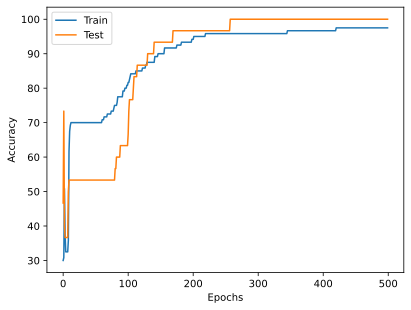

In [7]:
plt.plot(train_acc, label='Train')
plt.plot(test_acc, label='Test')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [8]:
train_sizes = np.linspace(.2,.95,10)
num_epochs = 200
train_accs = np.zeros((len(train_sizes), num_epochs))
test_accs = np.zeros((len(train_sizes), num_epochs))

for i, train_size in enumerate(train_sizes):
  model, loss_func, optimizer = create_model()
  train_acc, test_acc = train_model(
      X=X,
      Y = Y,
      model=model,
      loss_func=loss_func,
      optimizer=optimizer,
      train_prop=train_size,
      epochs=num_epochs
  )
  train_accs[i] = train_acc
  test_accs[i] = test_acc

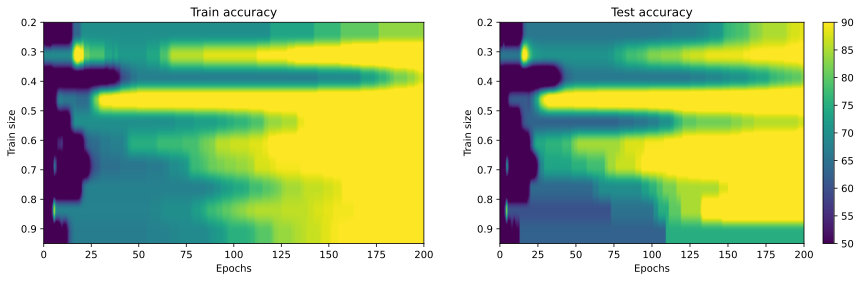

In [9]:
fig, ax = plt.subplots(1,2,figsize=(15,4))

ax[0].imshow(train_accs, aspect='auto', vmin=50,vmax=90, extent=[0, num_epochs, train_sizes[-1], train_sizes[0]])
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Train size')
ax[0].set_title('Train accuracy')

p = ax[1].imshow(test_accs, aspect='auto', vmin=50,vmax=90, extent=[0, num_epochs, train_sizes[-1], train_sizes[0]])
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Train size')
ax[1].set_title('Test accuracy')
fig.colorbar(p, ax=ax[1])
plt.show();

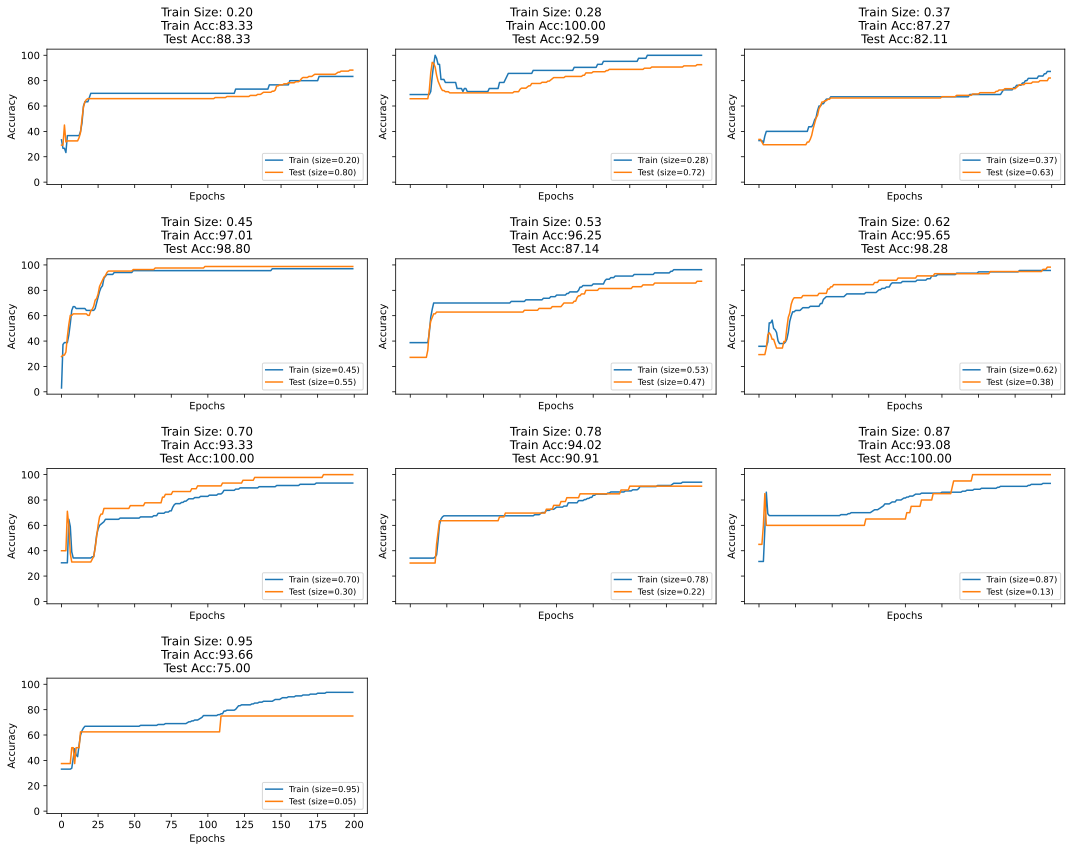

In [16]:
# Calculate the number of rows and columns for subplots
num_train_sizes = len(train_sizes)
num_cols = 3  # You can adjust this
num_rows = int(np.ceil(num_train_sizes / num_cols))

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows), sharex=True, sharey=True)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot data on each subplot
for i, train_size in enumerate(train_sizes):
    ax = axes[i]  # Get the current subplot axis
    ax.plot(train_accs[i], label=f'Train (size={train_size:.2f})')
    ax.plot(test_accs[i], label=f'Test (size={(1 - train_size):.2f})')
    ax.set_title(f'Train Size: {train_size:.2f}\nTrain Acc:{train_accs[i][-1]:.2f}\nTest Acc:{test_accs[i][-1]:.2f}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right', fontsize='small')

# Hide any unused subplots
for j in range(num_train_sizes, len(axes)):
    axes[j].axis('off')

plt.tight_layout()  # Adjust spacing between subplots
plt.show()